In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df = pd.read_csv(path)

df.head(), df.shape, df.columns.tolist()[:30]


(  component   model  year  month  value
 0   Drought  CHIRPS  2010     11  -0.06
 1   Drought  CHIRPS  2010     12  -0.04
 2   Drought  CHIRPS  2011      1  -0.21
 3   Drought  CHIRPS  2011      2  -0.22
 4   Drought  CHIRPS  2011      3  -0.24,
 (181, 5),
 ['component', 'model', 'year', 'month', 'value'])

In [ ]:
# Prepare a proper monthly datetime index
df2 = df.copy()
df2["date"] = pd.to_datetime(dict(year=df2["year"], month=df2["month"], day=1))
df2 = df2.sort_values("date").reset_index(drop=True)

# Sanity checks
date_min, date_max = df2["date"].min(), df2["date"].max()
missing_months = pd.date_range(date_min, date_max, freq="MS").difference(df2["date"])

date_min, date_max, len(missing_months), list(missing_months[:5])


(Timestamp('2010-11-01 00:00:00'), Timestamp('2025-11-01 00:00:00'), 0, [])

In [ ]:
# Create lag and rolling features for pure ML forecasting
y = df2["value"].astype(float).values

max_lag = 12
X = {}
for lag in range(1, max_lag + 1):
    X[f"lag_{lag}"] = pd.Series(y).shift(lag)

s = pd.Series(y)
X["roll_mean_3"] = s.shift(1).rolling(3).mean()
X["roll_mean_6"] = s.shift(1).rolling(6).mean()
X["roll_mean_12"] = s.shift(1).rolling(12).mean()
X["roll_std_3"] = s.shift(1).rolling(3).std()
X["roll_std_6"] = s.shift(1).rolling(6).std()
X["roll_std_12"] = s.shift(1).rolling(12).std()

# Seasonality feature
X["month_sin"] = np.sin(2 * np.pi * df2["month"] / 12)
X["month_cos"] = np.cos(2 * np.pi * df2["month"] / 12)

X = pd.DataFrame(X)
data = pd.concat([df2[["date", "value"]], X], axis=1).dropna().reset_index(drop=True)

# Target is next-month value
data["target_next"] = data["value"].shift(-1)
data = data.dropna().reset_index(drop=True)

data.head(), data.shape


(        date  value  lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  lag_8  \
 0 2011-11-01  -0.26  -0.25  -0.23  -0.22  -0.22  -0.22  -0.19  -0.20  -0.24   
 1 2011-12-01  -0.22  -0.26  -0.25  -0.23  -0.22  -0.22  -0.22  -0.19  -0.20   
 2 2012-01-01  -0.19  -0.22  -0.26  -0.25  -0.23  -0.22  -0.22  -0.22  -0.19   
 3 2012-02-01  -0.19  -0.19  -0.22  -0.26  -0.25  -0.23  -0.22  -0.22  -0.22   
 4 2012-03-01  -0.06  -0.19  -0.19  -0.22  -0.26  -0.25  -0.23  -0.22  -0.22   
 
    ...  lag_12  roll_mean_3  roll_mean_6  roll_mean_12  roll_std_3  \
 0  ...   -0.06    -0.233333    -0.221667     -0.191667    0.015275   
 1  ...   -0.04    -0.246667    -0.233333     -0.208333    0.015275   
 2  ...   -0.21    -0.243333    -0.233333     -0.223333    0.020817   
 3  ...   -0.22    -0.223333    -0.228333     -0.221667    0.035119   
 4  ...   -0.24    -0.200000    -0.223333     -0.219167    0.017321   
 
    roll_std_6  roll_std_12     month_sin     month_cos  target_next  
 0    0.019408     

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Use a simple, strong ML baseline: XGBoost if available; otherwise fallback to RandomForest
use_xgb = True
try:
    from xgboost import XGBRegressor
except Exception as e:
    use_xgb = False
    from sklearn.ensemble import RandomForestRegressor

features = [c for c in data.columns if c not in ("date", "target_next")]
X_mat = data[features].values
y_vec = data["target_next"].values
dates = data["date"].values

# Walk-forward evaluation with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=6)
preds = np.full_like(y_vec, fill_value=np.nan, dtype=float)

for train_idx, test_idx in tscv.split(X_mat):
    X_train, y_train = X_mat[train_idx], y_vec[train_idx]
    X_test = X_mat[test_idx]
    if use_xgb:
        model = XGBRegressor(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            objective="reg:squarederror",
        )
    else:
        model = RandomForestRegressor(
            n_estimators=800,
            random_state=42,
            min_samples_leaf=2,
        )
    model.fit(X_train, y_train)
    preds[test_idx] = model.predict(X_test)

# Compute metrics on all predicted points
mask = ~np.isnan(preds)
mae = mean_absolute_error(y_vec[mask], preds[mask])
rmse = np.sqrt(mean_squared_error(y_vec[mask], preds[mask]))

# MAPE can be unstable near zero; compute a "safe MAPE" with small epsilon
eps = 1e-6
mape = np.mean(np.abs((y_vec[mask] - preds[mask]) / (np.abs(y_vec[mask]) + eps))) * 100

mae, rmse, mape, use_xgb

(0.18663590945523337,
 np.float64(0.284670033399941),
 np.float64(144.01594704877283),
 True)

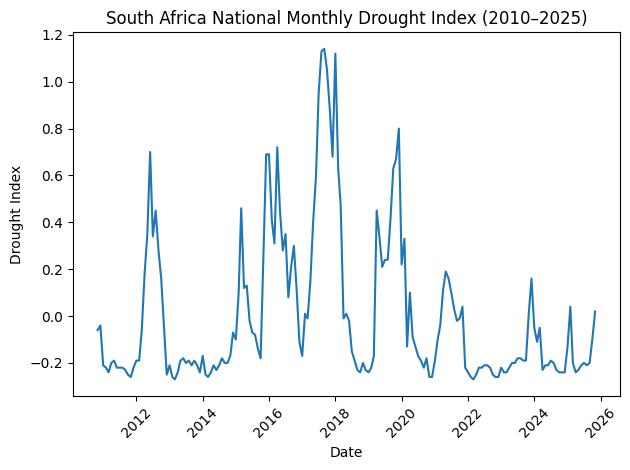

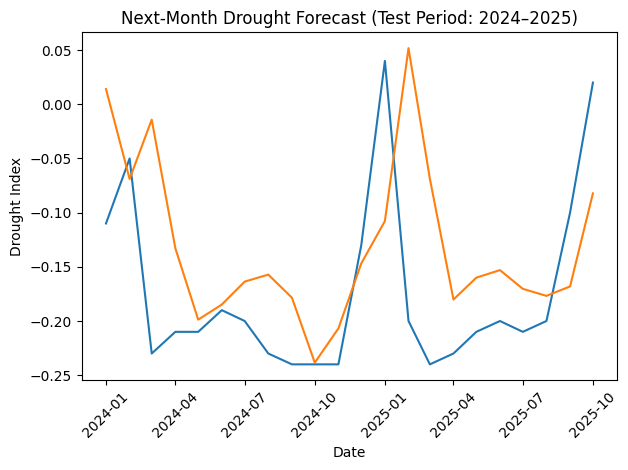

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recreate model quickly (fast Ridge) to ensure we have predictions
from sklearn.linear_model import Ridge

features = [c for c in data.columns if c not in ("date", "target_next")]
X = data[features]
y = data["target_next"]
dates = data["date"]

train_mask = dates < np.datetime64("2024-01-01")
test_mask = ~train_mask

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
dates_test = dates[test_mask]

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --------------------
# Plot 1: Full drought time series
# --------------------
plt.figure()
plt.plot(df2["date"], df2["value"])
plt.title("South Africa National Monthly Drought Index (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------
# Plot 2: Out-of-time Forecast (2024–2025)
# --------------------
plt.figure()
plt.plot(dates_test, y_test.values)
plt.plot(dates_test, y_pred)
plt.title("Next-Month Drought Forecast (Test Period: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


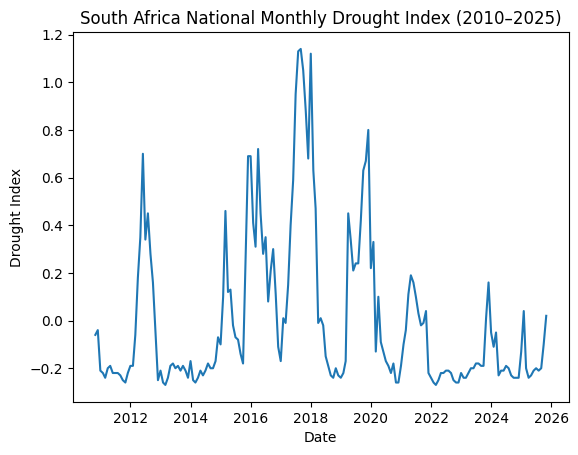

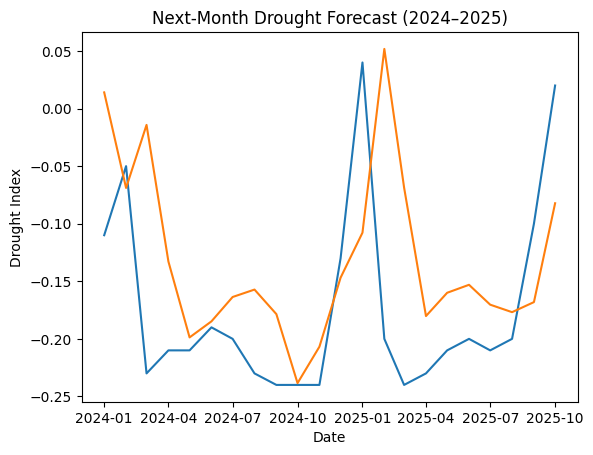

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Full drought time series
plt.figure()
plt.plot(df2["date"], df2["value"])
plt.title("South Africa National Monthly Drought Index (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.show()

# Plot 2: Forecast vs Actual (2024–2025)
plt.figure()
plt.plot(dates_test, y_test.values)
plt.plot(dates_test, y_pred)
plt.title("Next-Month Drought Forecast (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.show()


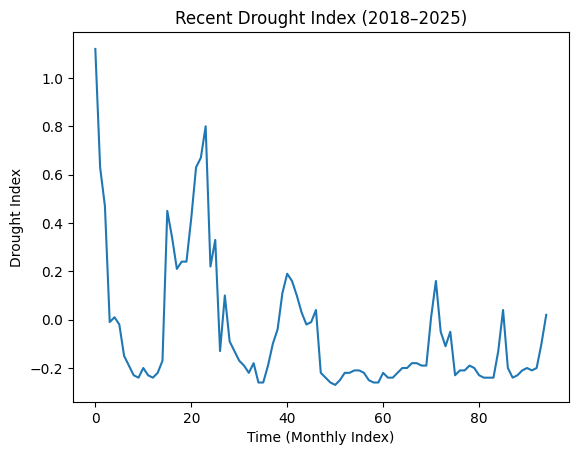

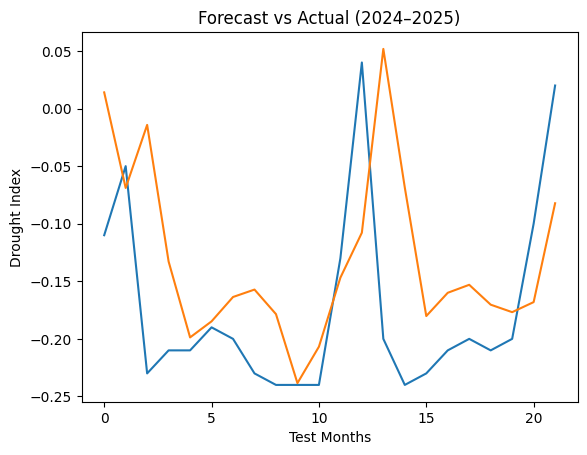

In [ ]:
import matplotlib.pyplot as plt

# Reduce data to recent years for faster rendering
recent_mask = df2["date"] >= "2018-01-01"
recent_df = df2[recent_mask]

plt.figure()
plt.plot(range(len(recent_df)), recent_df["value"])
plt.title("Recent Drought Index (2018–2025)")
plt.xlabel("Time (Monthly Index)")
plt.ylabel("Drought Index")
plt.show()

# Forecast plot (numeric x-axis for speed)
plt.figure()
plt.plot(range(len(y_test)), y_test.values)
plt.plot(range(len(y_test)), y_pred)
plt.title("Forecast vs Actual (2024–2025)")
plt.xlabel("Test Months")
plt.ylabel("Drought Index")
plt.show()


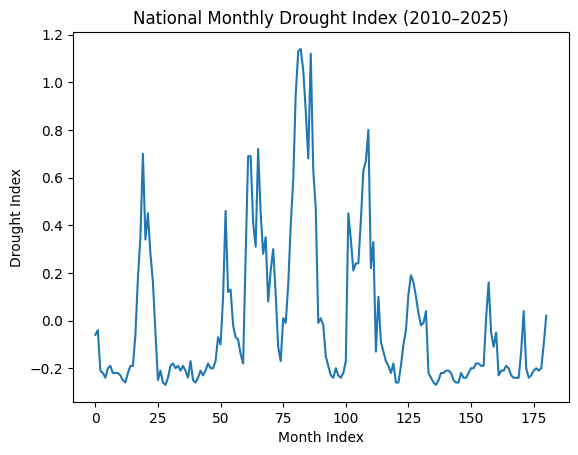

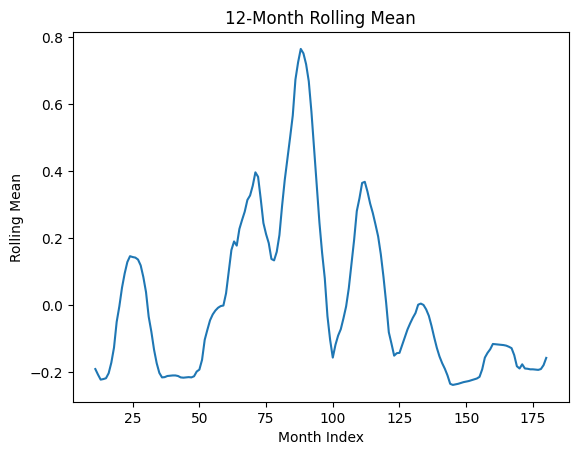

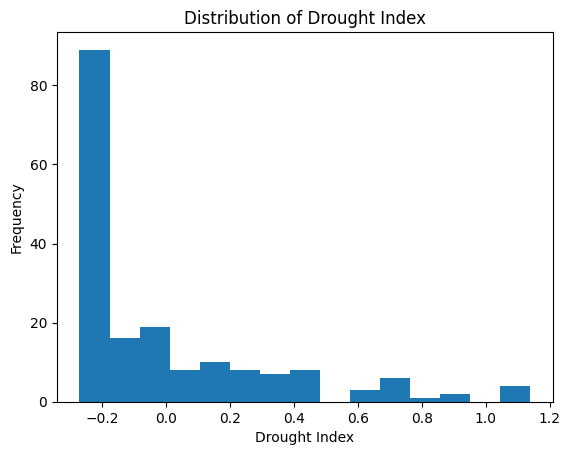

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload quickly
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
df = df.sort_values("date")

# 1️⃣ Full drought series
plt.figure()
plt.plot(df["value"])
plt.title("National Monthly Drought Index (2010–2025)")
plt.xlabel("Month Index")
plt.ylabel("Drought Index")
plt.show()

# 2️⃣ 12-month rolling average
plt.figure()
plt.plot(df["value"].rolling(12).mean())
plt.title("12-Month Rolling Mean")
plt.xlabel("Month Index")
plt.ylabel("Rolling Mean")
plt.show()

# 3️⃣ Distribution
plt.figure()
plt.hist(df["value"], bins=15)
plt.title("Distribution of Drought Index")
plt.xlabel("Drought Index")
plt.ylabel("Frequency")
plt.show()

================================================================================

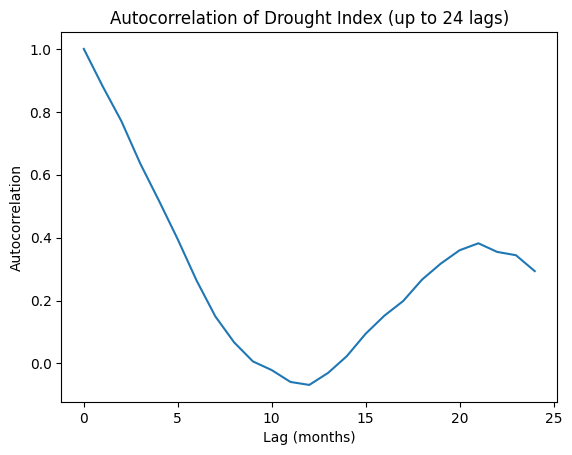

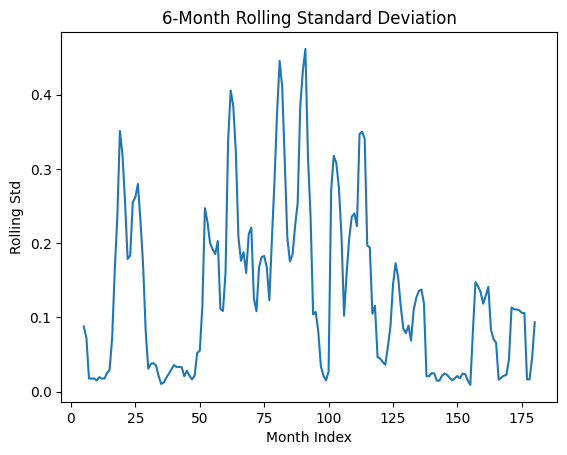

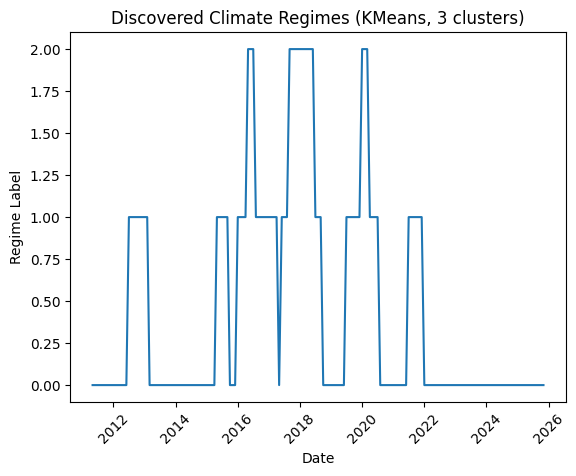

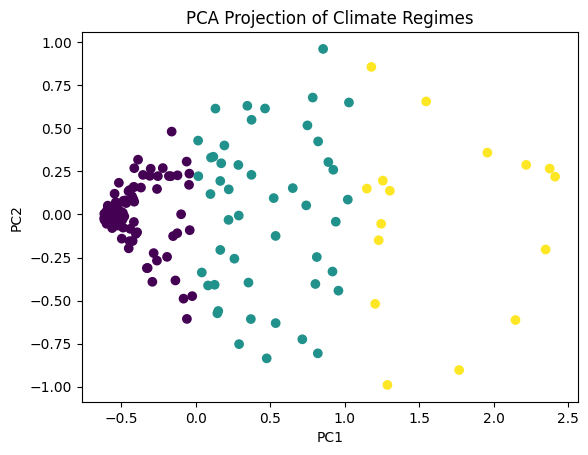

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
df = df.sort_values("date").reset_index(drop=True)

series = df["value"].values

# ---------------------------
# 1) Autocorrelation Analysis
# ---------------------------
max_lag = 24
acf_vals = [1.0]
for lag in range(1, max_lag + 1):
    acf_vals.append(np.corrcoef(series[:-lag], series[lag:])[0,1])

plt.figure()
plt.plot(range(0, max_lag + 1), acf_vals)
plt.title("Autocorrelation of Drought Index (up to 24 lags)")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.show()

# ---------------------------
# 2) Rolling Volatility (6-month std)
# ---------------------------
rolling_std = pd.Series(series).rolling(6).std()

plt.figure()
plt.plot(rolling_std)
plt.title("6-Month Rolling Standard Deviation")
plt.xlabel("Month Index")
plt.ylabel("Rolling Std")
plt.show()

# ---------------------------
# 3) Regime Discovery via KMeans
# ---------------------------
window = 6
X = []
dates = []

for i in range(window, len(series)):
    X.append(series[i-window:i])
    dates.append(df["date"].iloc[i])

X = np.array(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure()
plt.plot(dates, labels)
plt.title("Discovered Climate Regimes (KMeans, 3 clusters)")
plt.xlabel("Date")
plt.ylabel("Regime Label")
plt.xticks(rotation=45)
plt.show()

# ---------------------------
# 4) PCA Visualization of Regimes
# ---------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("PCA Projection of Climate Regimes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


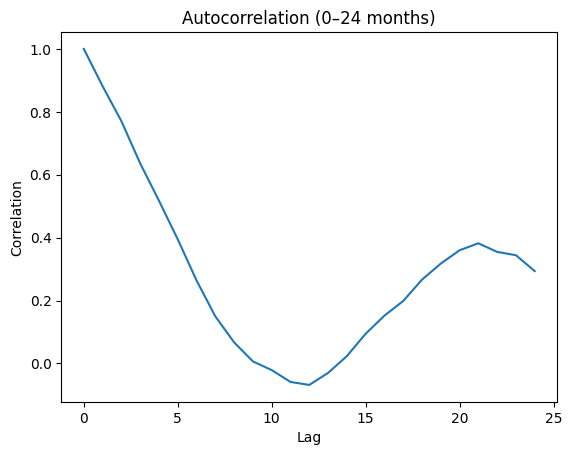

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
series = df["value"].values

max_lag = 24
acf_vals = [1.0]
for lag in range(1, max_lag + 1):
    acf_vals.append(np.corrcoef(series[:-lag], series[lag:])[0,1])

plt.figure()
plt.plot(range(0, max_lag + 1), acf_vals)
plt.title("Autocorrelation (0–24 months)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

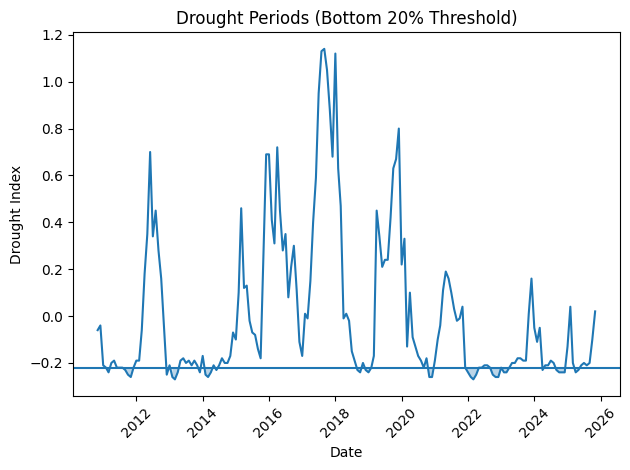

np.float64(-0.22)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
df = df.sort_values("date").reset_index(drop=True)

values = df["value"].values

# Define drought threshold as bottom 20% of values
threshold = np.percentile(values, 20)

# Create drought mask
drought_mask = values <= threshold

# Plot single figure (no specific colors used)
plt.figure()
plt.plot(df["date"], values)
plt.fill_between(df["date"], values, threshold, where=drought_mask, alpha=0.3)
plt.axhline(threshold)
plt.title("Drought Periods (Bottom 20% Threshold)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

threshold


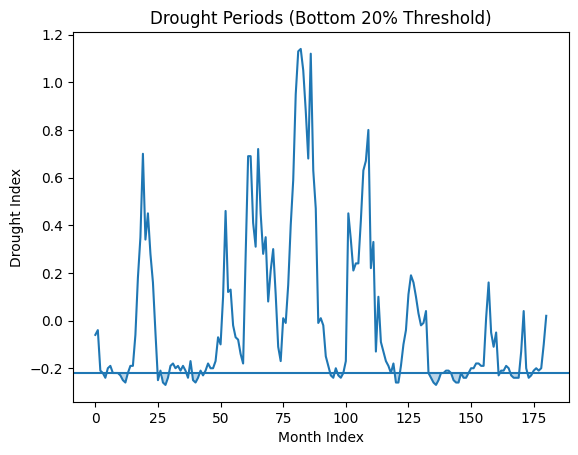

Drought threshold: -0.22


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
values = df["value"].values

threshold = np.percentile(values, 20)
drought_mask = values <= threshold

plt.figure()
plt.plot(values)
plt.fill_between(range(len(values)), values, threshold, where=drought_mask, alpha=0.3)
plt.axhline(threshold)
plt.title("Drought Periods (Bottom 20% Threshold)")
plt.xlabel("Month Index")
plt.ylabel("Drought Index")
plt.show()

print("Drought threshold:", threshold)

Compare with ONI

In [ ]:
import pandas as pd
import re

file_path = "oni.txt"

# Read and clean
rows = []
with open(file_path, "r") as f:
    for line in f:
        line = line.strip()
        # Skip empty lines or lines that are clearly headers
        if not line or line.startswith("Year") or line.startswith("DJF"):
            continue

        parts = re.split(r"\s+", line)
        # Ensure the first part is a digit (year) and there are enough parts for values
        if parts and parts[0].isdigit() and len(parts) > 1:
            year = int(parts[0])
            try:
                # Convert values to float; handle potential non-numeric entries (e.g., '***')
                values = []
                for val_str in parts[1:]:
                    if val_str == "***": # Common representation for missing data in ONI files
                        values.append(np.nan)
                    else:
                        values.append(float(val_str))
                rows.append([year] + values)
            except ValueError:
                # Skip lines where value conversion fails (e.g., unexpected format)
                print(f"Warning: Skipping line due to non-float values after year: {line}")
                continue
        else:
            # Skip malformed lines that don't start with a year or don't have enough data
            print(f"Warning: Skipping malformed line: {line}")
            continue

columns = ["Year","DJF","JFM","FMA","MAM","AMJ","MJJ",
           "JJA","JAS","ASO","SON","OND","NDJ"]

df = pd.DataFrame(rows, columns=columns)

output_path = "oni.csv"
df.to_csv(output_path, index=False)

output_path

'oni.csv'

Correlation: 0.18989649216530102


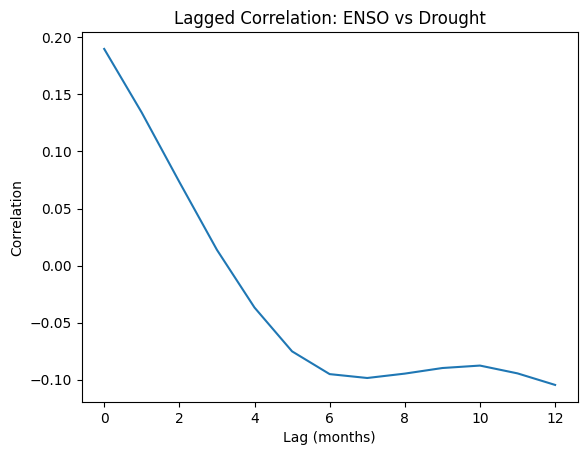

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load drought
drought = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
drought["date"] = pd.to_datetime(dict(year=drought.year, month=drought.month, day=1))

# Load ENSO (ONI monthly)
enso = pd.read_csv("oni.csv")  # adjust column names accordingly

# --- Fix for enso DataFrame structure ---
# 1. Melt the DataFrame to long format
month_map = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
    'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}
enso_long = enso.melt(id_vars=['Year'], var_name='month_period', value_name='oni')

# 2. Map month_period to numerical month and create date column
enso_long['month'] = enso_long['month_period'].map(month_map)
enso_long['date'] = pd.to_datetime(dict(year=enso_long['Year'], month=enso_long['month'], day=1))

# 3. Keep only relevant columns and clean up
enso = enso_long[['date', 'oni']].dropna().sort_values('date').reset_index(drop=True)

# Merge
df = drought.merge(enso, on="date")

# Correlation
print("Correlation:", df["value"].corr(df["oni"]))

# Cross-correlation
max_lag = 12
lags = []
corrs = []
for lag in range(max_lag + 1):
    corr = np.corrcoef(df["value"][:-lag or None], df["oni"][lag:])[0,1]
    lags.append(lag)
    corrs.append(corr)

plt.figure()
plt.plot(lags, corrs)
plt.title("Lagged Correlation: ENSO vs Drought")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.show()

**HMM Analysis**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


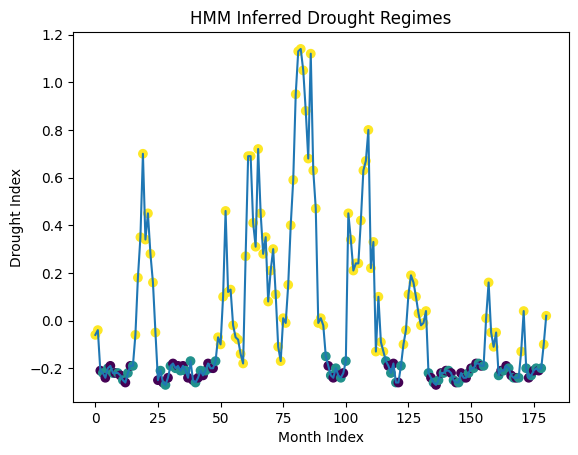

array([[3.67385499e-03, 9.96323487e-01, 2.65846064e-06],
       [8.46465516e-01, 4.51903691e-03, 1.49015448e-01],
       [2.78355849e-02, 5.54214871e-02, 9.16742928e-01]])

In [ ]:
# Hidden Markov Model for Drought Regime Detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM

# Load drought dataset
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")

# Extract drought index values
values = df["value"].values.reshape(-1, 1)

# Fit 3-state HMM (wet, normal, drought)
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
model.fit(values)

# Predict hidden states
hidden_states = model.predict(values)

# Add to dataframe
df["HMM_State"] = hidden_states

# Sort states by mean value (so lowest mean = drought state)
state_means = []
for i in range(3):
    state_means.append((i, values[hidden_states == i].mean()))

state_means_sorted = sorted(state_means, key=lambda x: x[1])

# Map states to ordered labels
state_mapping = {state_means_sorted[i][0]: i for i in range(3)}
df["Ordered_State"] = df["HMM_State"].map(state_mapping)

# Plot drought index with inferred regimes
plt.figure()
plt.plot(values.flatten())
plt.scatter(range(len(values)), values.flatten(), c=df["Ordered_State"])
plt.title("HMM Inferred Drought Regimes")
plt.xlabel("Month Index")
plt.ylabel("Drought Index")
plt.show()

# Transition probabilities
transition_matrix = model.transmat_

transition_matrix

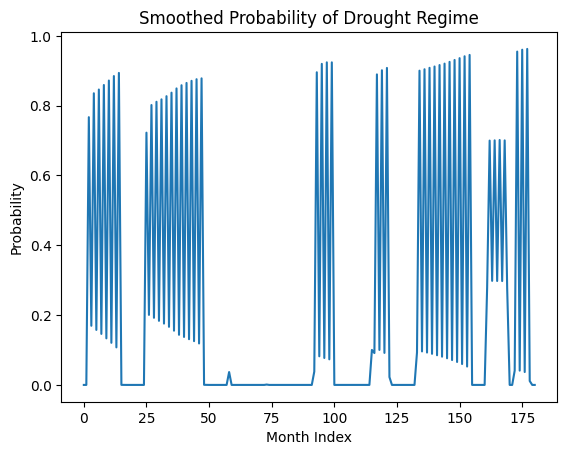

Current Drought Probability: 2.812451309690534e-14
Probability of Drought Next Month: 0.027835584881341777
Probability of Drought in 2 Months: 0.07253271716034342
Probability of Drought in 3 Months: 0.09058370307483027


In [ ]:
# Compute smoothed probabilities and 3-month drought entry probability

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# Load data
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
values = df["value"].values.reshape(-1, 1)

# Fit HMM again (consistent with earlier model)
model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=200, random_state=42)
model.fit(values)

# Get posterior (smoothed) probabilities
posterior_probs = model.predict_proba(values)

# Identify drought state (lowest mean)
state_means = [(i, values[model.predict(values) == i].mean()) for i in range(3)]
drought_state = sorted(state_means, key=lambda x: x[1])[0][0]

drought_prob_series = posterior_probs[:, drought_state]

# Plot smoothed probability of drought
plt.figure()
plt.plot(drought_prob_series)
plt.title("Smoothed Probability of Drought Regime")
plt.xlabel("Month Index")
plt.ylabel("Probability")
plt.show()

# --- Predict probability of entering drought next 3 months ---

transition_matrix = model.transmat_

# Current state probabilities (last observation posterior)
current_prob = posterior_probs[-1]

# Compute 1-step, 2-step, 3-step transition probabilities
one_step = current_prob @ transition_matrix
two_step = one_step @ transition_matrix
three_step = two_step @ transition_matrix

print("Current Drought Probability:", current_prob[drought_state])
print("Probability of Drought Next Month:", one_step[drought_state])
print("Probability of Drought in 2 Months:", two_step[drought_state])
print("Probability of Drought in 3 Months:", three_step[drought_state])


Threshold: 0.7
Number of drought episodes: 43

Longest drought episode:
 episode_id start_date   end_date  duration_months  avg_drought_prob  max_drought_prob  min_drought_index  mean_drought_index
         43 2025-08-01 2025-08-01                1           0.96251           0.96251              -0.21               -0.21

Saved episode table to: drought_episodes_hmm_threshold_0p7.csv


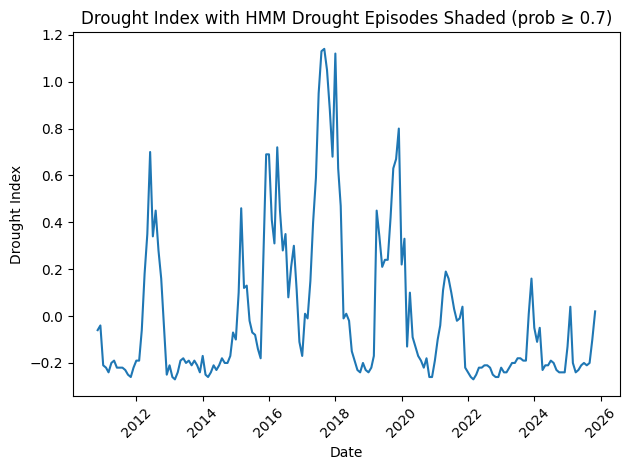

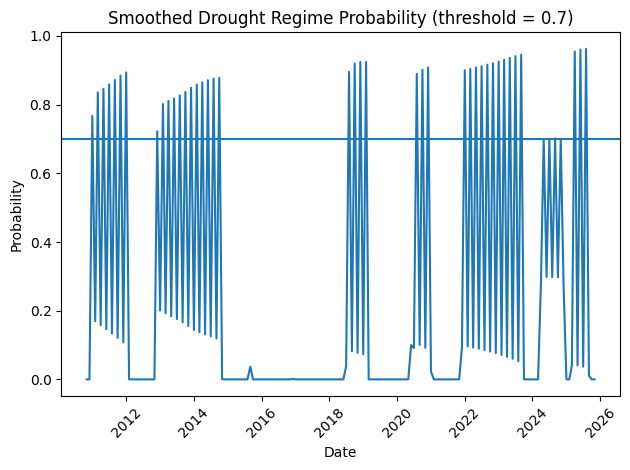

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Inputs you already have
# -----------------------------
# df: your drought dataframe (must have 'value' and either 'date' or (year, month))
# drought_prob_series: numpy array of length len(df) with smoothed drought probabilities

# If df doesn't have a datetime column yet, create one:
if "date" not in df.columns:
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)

# Make sure drought_prob_series aligns with df rows
drought_prob_series = np.asarray(drought_prob_series).reshape(-1)
assert len(drought_prob_series) == len(df), "drought_prob_series must align with df rows"

# -----------------------------
# 1) Define drought regime by threshold
# -----------------------------
threshold = 0.7
is_drought = drought_prob_series >= threshold

# Identify contiguous drought episodes
# Start = drought today and not drought yesterday
# End   = drought today and not drought tomorrow
starts = np.where(is_drought & ~np.r_[False, is_drought[:-1]])[0]
ends   = np.where(is_drought & ~np.r_[is_drought[1:], False])[0]

episodes = []
for s, e in zip(starts, ends):
    seg_probs = drought_prob_series[s:e+1]
    seg_vals = df["value"].iloc[s:e+1].values
    episodes.append({
        "episode_id": len(episodes) + 1,
        "start_date": df["date"].iloc[s],
        "end_date": df["date"].iloc[e],
        "duration_months": int(e - s + 1),
        "avg_drought_prob": float(np.mean(seg_probs)),
        "max_drought_prob": float(np.max(seg_probs)),
        "min_drought_index": float(np.min(seg_vals)),
        "mean_drought_index": float(np.mean(seg_vals)),
    })

episodes_df = pd.DataFrame(episodes)

# -----------------------------
# 2) Summary stats
# -----------------------------
num_episodes = len(episodes_df)
longest = episodes_df.sort_values(["duration_months", "avg_drought_prob"], ascending=[False, False]).head(1)

print(f"Threshold: {threshold}")
print(f"Number of drought episodes: {num_episodes}")
if num_episodes > 0:
    print("\nLongest drought episode:")
    print(longest.to_string(index=False))
else:
    print("No episodes found at this threshold.")

# -----------------------------
# 3) Save episode table to CSV
# -----------------------------
out_csv = "drought_episodes_hmm_threshold_0p7.csv"
episodes_df.to_csv(out_csv, index=False)
print(f"\nSaved episode table to: {out_csv}")

# -----------------------------
# 4) Plot with drought episodes shaded
# -----------------------------
plt.figure()
plt.plot(df["date"], df["value"])
# Shade drought episodes
for _, row in episodes_df.iterrows():
    plt.axvspan(row["start_date"], row["end_date"], alpha=0.25)
plt.title(f"Drought Index with HMM Drought Episodes Shaded (prob ≥ {threshold})")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: plot drought probability with threshold line
plt.figure()
plt.plot(df["date"], drought_prob_series)
plt.axhline(threshold)
plt.title(f"Smoothed Drought Regime Probability (threshold = {threshold})")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
for s in range(3):
    print(f"State {s} mean:", values[model.predict(values) == s].mean())

State 0 mean: -0.22000000000000008
State 1 mean: -0.21448979591836734
State 2 mean: 0.2353409090909091


Wet state identified as: 2
State means: [(0, np.float64(-0.22000000000000008)), (1, np.float64(-0.21448979591836734)), (2, np.float64(0.2353409090909091))]

Threshold: 0.7
Number of DRY (drought) episodes: 7

Longest DRY episode:
 episode_id start_date   end_date  duration_months  avg_dry_prob  max_dry_prob  min_drought_index  mean_drought_index
          2 2012-12-01 2014-11-01               24      0.991048      0.999761              -0.27              -0.215

Saved episode table to: dry_episodes_hmm_threshold_0p7.csv


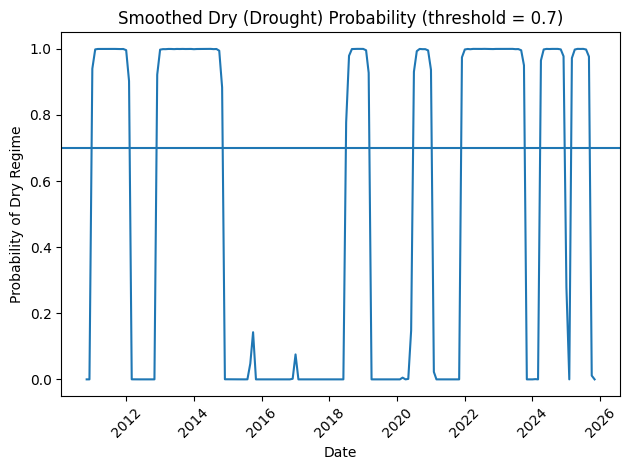

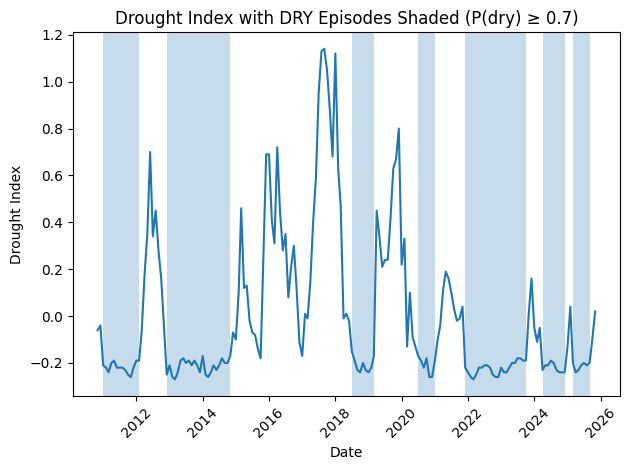

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have:
# df = drought dataframe with 'value' and date info
# posterior_probs = model.predict_proba(values)
# and you've confirmed state means:
# State 2 is wet regime

# --- Make sure df has date ---
if "date" not in df.columns:
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)

# --- Identify wet state (highest mean) ---
state_means = []
for s in range(posterior_probs.shape[1]):
    state_means.append((s, df.loc[df.index, "value"].values[model.predict(values) == s].mean()))
wet_state = sorted(state_means, key=lambda x: x[1])[-1][0]  # highest mean state

print("Wet state identified as:", wet_state)
print("State means:", state_means)

# --- Drought (dry) probability = 1 - wet probability ---
wet_prob = posterior_probs[:, wet_state]
dry_prob = 1.0 - wet_prob

# --- Define drought episodes ---
threshold = 0.7  # you can change to 0.6 or 0.8
is_dry = dry_prob >= threshold

starts = np.where(is_dry & ~np.r_[False, is_dry[:-1]])[0]
ends   = np.where(is_dry & ~np.r_[is_dry[1:], False])[0]

episodes = []
for s, e in zip(starts, ends):
    seg_probs = dry_prob[s:e+1]
    seg_vals = df["value"].iloc[s:e+1].values
    episodes.append({
        "episode_id": len(episodes) + 1,
        "start_date": df["date"].iloc[s],
        "end_date": df["date"].iloc[e],
        "duration_months": int(e - s + 1),
        "avg_dry_prob": float(np.mean(seg_probs)),
        "max_dry_prob": float(np.max(seg_probs)),
        "min_drought_index": float(np.min(seg_vals)),
        "mean_drought_index": float(np.mean(seg_vals)),
    })

episodes_df = pd.DataFrame(episodes)

print("\nThreshold:", threshold)
print("Number of DRY (drought) episodes:", len(episodes_df))
if len(episodes_df) > 0:
    longest = episodes_df.sort_values(["duration_months", "avg_dry_prob"], ascending=[False, False]).head(1)
    print("\nLongest DRY episode:")
    print(longest.to_string(index=False))
else:
    print("No dry episodes found at this threshold.")

# --- Save episodes table ---
out_csv = f"dry_episodes_hmm_threshold_{str(threshold).replace('.','p')}.csv"
episodes_df.to_csv(out_csv, index=False)
print("\nSaved episode table to:", out_csv)

# --- Plot 1: Dry probability with threshold ---
plt.figure()
plt.plot(df["date"], dry_prob)
plt.axhline(threshold)
plt.title(f"Smoothed Dry (Drought) Probability (threshold = {threshold})")
plt.xlabel("Date")
plt.ylabel("Probability of Dry Regime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot 2: Drought index with dry episodes shaded ---
plt.figure()
plt.plot(df["date"], df["value"])
for _, row in episodes_df.iterrows():
    plt.axvspan(row["start_date"], row["end_date"], alpha=0.25)
plt.title(f"Drought Index with DRY Episodes Shaded (P(dry) ≥ {threshold})")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# --- Identify drought and wet states ---
is_wet = ~is_dry

# --- Function to compute episode durations ---
def compute_durations(binary_series):
    starts = np.where(binary_series & ~np.r_[False, binary_series[:-1]])[0]
    ends   = np.where(binary_series & ~np.r_[binary_series[1:], False])[0]
    durations = [e - s + 1 for s, e in zip(starts, ends)]
    return durations

# --- Compute durations ---
drought_durations = compute_durations(is_dry)
wet_durations = compute_durations(is_wet)

# --- Total percentage time in drought ---
total_months = len(is_dry)
drought_months = np.sum(is_dry)
wet_months = np.sum(is_wet)

pct_drought = 100 * drought_months / total_months
pct_wet = 100 * wet_months / total_months

# --- Summary statistics ---
results = {
    "Total months": total_months,
    "Drought months": drought_months,
    "Wet months": wet_months,
    "Percent time in drought": pct_drought,
    "Percent time in wet": pct_wet,
    "Number of drought episodes": len(drought_durations),
    "Mean drought duration (months)": np.mean(drought_durations),
    "Median drought duration (months)": np.median(drought_durations),
    "Mean wet duration (months)": np.mean(wet_durations),
    "Median wet duration (months)": np.median(wet_durations),
}

for k, v in results.items():
    print(f"{k}: {v}")

Total months: 181
Drought months: 93
Wet months: 88
Percent time in drought: 51.38121546961326
Percent time in wet: 48.61878453038674
Number of drought episodes: 7
Mean drought duration (months): 13.285714285714286
Median drought duration (months): 9.0
Mean wet duration (months): 11.0
Median wet duration (months): 7.0


In [ ]:
import numpy as np

# is_dry is your binary drought indicator (thresholded)

exits = 0
total_drought_months = 0

for t in range(len(is_dry)-1):
    if is_dry[t]:
        total_drought_months += 1
        if not is_dry[t+1]:
            exits += 1

hazard_rate = exits / total_drought_months

print("Empirical monthly hazard rate (exit drought):", hazard_rate)

expected_duration = 1 / hazard_rate
print("Expected drought duration (months):", expected_duration)

Empirical monthly hazard rate (exit drought): 0.07526881720430108
Expected drought duration (months): 13.285714285714285


In [ ]:
!pip install hmmlearn statsmodels tensorflow

In [ ]:
import numpy as np
import pandas as pd

from hmmlearn.hmm import GaussianHMM

# Load
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)

y = df["value"].astype(float).values.reshape(-1, 1)

# Fit HMM (3 states, diag covariance = stable)
hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=300, random_state=42)
hmm.fit(y)

post = hmm.predict_proba(y)                    # smoothed posterior probs
states = hmm.predict(y)

# Identify wet state (highest mean)
state_means = [(s, y[states == s].mean()) for s in range(3)]
wet_state = sorted(state_means, key=lambda x: x[1])[-1][0]

wet_prob = post[:, wet_state]
dry_prob = 1.0 - wet_prob

df["wet_prob"] = wet_prob
df["dry_prob"] = dry_prob

print("State means:", state_means, "Wet state:", wet_state)

State means: [(0, np.float64(-0.22000000000000008)), (1, np.float64(-0.21448979591836734)), (2, np.float64(0.2353409090909091))] Wet state: 2


In [ ]:
import numpy as np
import pandas as pd

from hmmlearn.hmm import GaussianHMM

# Load
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)

y = df["value"].astype(float).values.reshape(-1, 1)

# Fit HMM (3 states, diag covariance = stable)
hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=300, random_state=42)
hmm.fit(y)

post = hmm.predict_proba(y)                    # smoothed posterior probs
states = hmm.predict(y)

# Identify wet state (highest mean)
state_means = [(s, y[states == s].mean()) for s in range(3)]
wet_state = sorted(state_means, key=lambda x: x[1])[-1][0]

wet_prob = post[:, wet_state]
dry_prob = 1.0 - wet_prob

df["wet_prob"] = wet_prob
df["dry_prob"] = dry_prob

print("State means:", state_means, "Wet state:", wet_state)

State means: [(0, np.float64(-0.22000000000000008)), (1, np.float64(-0.21448979591836734)), (2, np.float64(0.2353409090909091))] Wet state: 2


In [ ]:
def make_supervised(y_series, x_features=None, lookback=12, horizon=1):
    """
    y_series: shape [T]
    x_features: shape [T, F] or None
    returns X, y where:
      X: [N, lookback, F_total]
      y: [N]
    """
    y_series = np.asarray(y_series).reshape(-1)
    T = len(y_series)

    if x_features is None:
        x_features = y_series.reshape(-1, 1)
    else:
        x_features = np.asarray(x_features)
        if x_features.ndim == 1:
            x_features = x_features.reshape(-1, 1)

    X, Y = [], []
    for t in range(lookback, T - horizon + 1):
        X.append(x_features[t - lookback:t])
        Y.append(y_series[t + horizon - 1])
    return np.array(X), np.array(Y)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(a,b):
    return np.sqrt(mean_squared_error(a,b))

def eval_forecasts(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r = rmse(y_true, y_pred)
    return mae, r

# Train/test split (out-of-time)
split_date = np.datetime64("2024-01-01")
train_mask = df["date"].values < split_date
test_mask  = ~train_mask

y_all = df["value"].values
y_train = y_all[train_mask]
y_test  = y_all[test_mask]

# HMM pieces
P = hmm.transmat_
# state means from fitted states (stable)
mu = np.array([y[states == s].mean() for s in range(3)]).reshape(-1)  # [3]
post_all = post  # [T,3]

def hmm_expected_forecast(t_index, horizon):
    # posterior at time t_index
    pi = post_all[t_index]  # [3]
    Ph = np.linalg.matrix_power(P, horizon)
    pi_h = pi @ Ph
    return float(pi_h @ mu)

# Evaluate horizons 1..6 on test region
results = []

# indices for test region in full timeline
test_indices = np.where(test_mask)[0]

for h in range(1, 7):
    # --- Naive persistence ---
    naive_preds = []
    naive_true  = []

    # --- HMM expected value ---
    hmm_preds = []
    hmm_true  = []

    # ARIMA: fit once on TRAIN then dynamic forecast for test
    # (simple approach; more rigorous = rolling refit)
    arima_model = ARIMA(y_train, order=(1,0,0)).fit()
    # forecast length needed: test length + h -1 (so we can align)
    arima_forecast = arima_model.forecast(steps=len(y_test)+h-1)

    for i, t in enumerate(test_indices):
        # need y_t for naive, and y_{t+h} exists
        if t + h >= len(y_all):
            continue
        naive_preds.append(y_all[t])
        naive_true.append(y_all[t+h])

        hmm_preds.append(hmm_expected_forecast(t, h))
        hmm_true.append(y_all[t+h])

    # Align ARIMA forecast to true points
    # We want predictions for each test time t at horizon h.
    # First test corresponds to position len(train), horizon h => arima_forecast[h-1]
    arima_preds = arima_forecast[(h-1):(h-1)+len(naive_true)]

    mae_n, rmse_n = eval_forecasts(np.array(naive_true), np.array(naive_preds))
    mae_h, rmse_h = eval_forecasts(np.array(hmm_true),   np.array(hmm_preds))
    mae_a, rmse_a = eval_forecasts(np.array(naive_true), np.array(arima_preds))

    results.append([h, mae_n, rmse_n, mae_a, rmse_a, mae_h, rmse_h])

res_df = pd.DataFrame(results, columns=[
    "horizon_months",
    "naive_MAE","naive_RMSE",
    "ARIMA_MAE","ARIMA_RMSE",
    "HMM_MAE","HMM_RMSE"
])
res_df

,horizon_months,naive_MAE,naive_RMSE,ARIMA_MAE,ARIMA_RMSE,HMM_MAE,HMM_RMSE
0,1,0.055909,0.087100,0.242492,0.257420,0.102217,0.160323
1,2,0.075238,0.115717,0.241949,0.257587,0.137654,0.183886
2,3,0.091500,0.125797,0.245058,0.260869,0.154843,0.196351
3,4,0.091053,0.122753,0.239673,0.255506,0.159665,0.188402
4,5,0.090000,0.123333,0.235403,0.251682,0.169039,0.188733
5,6,0.091765,0.127094,0.231190,0.248042,0.171625,0.189733


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm(input_shape):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(32, dropout=0.1, recurrent_dropout=0.0),
        layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")
    return m

def build_gru(input_shape):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(32, dropout=0.1, recurrent_dropout=0.0),
        layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")
    return m

def train_and_eval_rnn(model_builder, y_series, features, dates, lookback=12, horizon=1):
    X, Y = make_supervised(y_series, features, lookback=lookback, horizon=horizon)

    # Align dates to supervised rows
    # First supervised target corresponds to index lookback + horizon - 1
    tgt_idx = np.arange(lookback + horizon - 1, len(y_series))
    dates_sup = dates[tgt_idx]

    # out-of-time split on supervised rows
    train_mask = dates_sup < np.datetime64("2024-01-01")
    test_mask  = ~train_mask

    X_train, y_train = X[train_mask], Y[train_mask]
    X_test,  y_test  = X[test_mask],  Y[test_mask]

    # small dataset: use early stopping
    model = model_builder(X_train.shape[1:])
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=300,
        batch_size=16,
        verbose=0,
        callbacks=[cb]
    )

    y_pred = model.predict(X_test, verbose=0).reshape(-1)
    mae, r = eval_forecasts(y_test, y_pred)
    return mae, r

In [ ]:
y_series = df["value"].values
dates = df["date"].values

# Feature sets
feat_uni = None  # uses y itself
feat_hybrid = np.column_stack([df["value"].values, df["dry_prob"].values])  # y + drought regime prob

rows = []
for h in range(1, 7):
    # LSTM
    mae_l_u, rmse_l_u = train_and_eval_rnn(build_lstm, y_series, feat_uni, dates, lookback=12, horizon=h)
    mae_l_h, rmse_l_h = train_and_eval_rnn(build_lstm, y_series, feat_hybrid, dates, lookback=12, horizon=h)

    # GRU
    mae_g_u, rmse_g_u = train_and_eval_rnn(build_gru, y_series, feat_uni, dates, lookback=12, horizon=h)
    mae_g_h, rmse_g_h = train_and_eval_rnn(build_gru, y_series, feat_hybrid, dates, lookback=12, horizon=h)

    rows.append([h,
                 mae_l_u, rmse_l_u, mae_l_h, rmse_l_h,
                 mae_g_u, rmse_g_u, mae_g_h, rmse_g_h])

rnn_df = pd.DataFrame(rows, columns=[
    "horizon",
    "LSTM_MAE_uni","LSTM_RMSE_uni","LSTM_MAE_hybrid","LSTM_RMSE_hybrid",
    "GRU_MAE_uni","GRU_RMSE_uni","GRU_MAE_hybrid","GRU_RMSE_hybrid",
])
rnn_df

,horizon,LSTM_MAE_uni,LSTM_RMSE_uni,LSTM_MAE_hybrid,LSTM_RMSE_hybrid,GRU_MAE_uni,GRU_RMSE_uni,GRU_MAE_hybrid,GRU_RMSE_hybrid
0,1,0.065325,0.089253,0.085520,0.114051,0.067098,0.091101,0.077327,0.106496
1,2,0.106195,0.117801,0.085228,0.101344,0.073727,0.090811,0.126720,0.161666
2,3,0.121321,0.132555,0.106447,0.119440,0.080482,0.096457,0.106230,0.135616
3,4,0.153654,0.166351,0.124206,0.135457,0.102514,0.112636,0.110180,0.128745
4,5,0.167554,0.180930,0.132450,0.149266,0.115747,0.126005,0.127407,0.142573
5,6,0.178682,0.192422,0.196711,0.214368,0.162592,0.175906,0.149983,0.177562


In [ ]:
final = res_df.merge(rnn_df, left_on="horizon_months", right_on="horizon").drop(columns=["horizon"])
final

,horizon_months,naive_MAE,naive_RMSE,ARIMA_MAE,ARIMA_RMSE,HMM_MAE,HMM_RMSE,LSTM_MAE_uni,LSTM_RMSE_uni,LSTM_MAE_hybrid,LSTM_RMSE_hybrid,GRU_MAE_uni,GRU_RMSE_uni,GRU_MAE_hybrid,GRU_RMSE_hybrid
0,1,0.055909,0.087100,0.242492,0.257420,0.102217,0.160323,0.065325,0.089253,0.085520,0.114051,0.067098,0.091101,0.077327,0.106496
1,2,0.075238,0.115717,0.241949,0.257587,0.137654,0.183886,0.106195,0.117801,0.085228,0.101344,0.073727,0.090811,0.126720,0.161666
2,3,0.091500,0.125797,0.245058,0.260869,0.154843,0.196351,0.121321,0.132555,0.106447,0.119440,0.080482,0.096457,0.106230,0.135616
3,4,0.091053,0.122753,0.239673,0.255506,0.159665,0.188402,0.153654,0.166351,0.124206,0.135457,0.102514,0.112636,0.110180,0.128745
4,5,0.090000,0.123333,0.235403,0.251682,0.169039,0.188733,0.167554,0.180930,0.132450,0.149266,0.115747,0.126005,0.127407,0.142573
5,6,0.091765,0.127094,0.231190,0.248042,0.171625,0.189733,0.178682,0.192422,0.196711,0.214368,0.162592,0.175906,0.149983,0.177562


**ML Piece**

In [ ]:
!pip install xgboost

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def rmse(a,b):
    return mean_squared_error(a,b, squared=False)

def make_lag_features(series, regime_prob, lags=12, horizon=1):
    X, Y = [], []
    for t in range(lags, len(series) - horizon):
        lag_vals = series[t-lags:t]
        features = np.concatenate([lag_vals, [regime_prob[t]]])
        X.append(features)
        Y.append(series[t+horizon])
    return np.array(X), np.array(Y)

In [ ]:
y_series = df["value"].values
dry_prob = df["dry_prob"].values
dates = df["date"].values

split_date = np.datetime64("2024-01-01")

xgb_rows = []

for h in range(1,7):
    X, Y = make_lag_features(y_series, dry_prob, lags=12, horizon=h)

    tgt_dates = dates[12+h:len(dates)]

    train_mask = tgt_dates < split_date
    test_mask  = ~train_mask

    X_train, y_train = X[train_mask], Y[train_mask]
    X_test,  y_test  = X[test_mask],  Y[test_mask]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r   = np.sqrt(mean_squared_error(y_test, y_pred))

    xgb_rows.append([h, mae, r])

xgb_df = pd.DataFrame(xgb_rows, columns=["horizon","XGB_MAE","XGB_RMSE"])
xgb_df

,horizon,XGB_MAE,XGB_RMSE
0,1,0.086307,0.127508
1,2,0.123438,0.171156
2,3,0.168919,0.211858
3,4,0.185433,0.223949
4,5,0.204524,0.259794
5,6,0.212718,0.272312


In [ ]:
comparison = final.merge(xgb_df, left_on="horizon_months", right_on="horizon").drop(columns=["horizon"])
comparison

,horizon_months,naive_MAE,naive_RMSE,ARIMA_MAE,ARIMA_RMSE,HMM_MAE,HMM_RMSE,LSTM_MAE_uni,LSTM_RMSE_uni,LSTM_MAE_hybrid,LSTM_RMSE_hybrid,GRU_MAE_uni,GRU_RMSE_uni,GRU_MAE_hybrid,GRU_RMSE_hybrid,XGB_MAE,XGB_RMSE
0,1,0.055909,0.087100,0.242492,0.257420,0.102217,0.160323,0.065325,0.089253,0.085520,0.114051,0.067098,0.091101,0.077327,0.106496,0.086307,0.127508
1,2,0.075238,0.115717,0.241949,0.257587,0.137654,0.183886,0.106195,0.117801,0.085228,0.101344,0.073727,0.090811,0.126720,0.161666,0.123438,0.171156
2,3,0.091500,0.125797,0.245058,0.260869,0.154843,0.196351,0.121321,0.132555,0.106447,0.119440,0.080482,0.096457,0.106230,0.135616,0.168919,0.211858
3,4,0.091053,0.122753,0.239673,0.255506,0.159665,0.188402,0.153654,0.166351,0.124206,0.135457,0.102514,0.112636,0.110180,0.128745,0.185433,0.223949
4,5,0.090000,0.123333,0.235403,0.251682,0.169039,0.188733,0.167554,0.180930,0.132450,0.149266,0.115747,0.126005,0.127407,0.142573,0.204524,0.259794
5,6,0.091765,0.127094,0.231190,0.248042,0.171625,0.189733,0.178682,0.192422,0.196711,0.214368,0.162592,0.175906,0.149983,0.177562,0.212718,0.272312


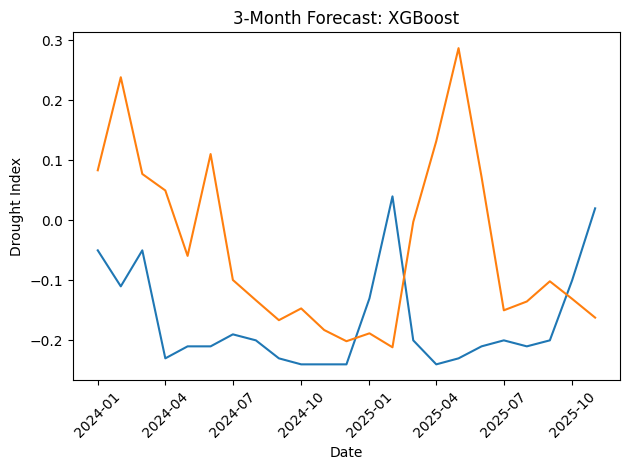

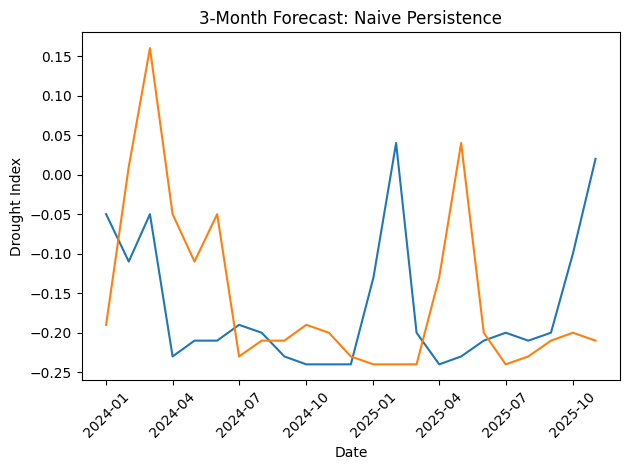

In [ ]:
h = 3

# Prepare test data
X, Y = make_lag_features(y_series, dry_prob, lags=12, horizon=h)
tgt_dates = dates[12+h:len(dates)]

train_mask = tgt_dates < split_date
test_mask  = ~train_mask

X_train, y_train = X[train_mask], Y[train_mask]
X_test,  y_test  = X[test_mask],  Y[test_mask]
test_dates = tgt_dates[test_mask]

# Refit XGBoost
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
xgb_pred = model.predict(X_test)

# Naive persistence
naive_pred = []
for i in range(len(test_dates)):
    idx = np.where(dates == test_dates[i])[0][0]
    naive_pred.append(y_series[idx-h])

naive_pred = np.array(naive_pred)

# Plot 1: Actual vs XGBoost
plt.figure()
plt.plot(test_dates, y_test)
plt.plot(test_dates, xgb_pred)
plt.title("3-Month Forecast: XGBoost")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Actual vs Naive
plt.figure()
plt.plot(test_dates, y_test)
plt.plot(test_dates, naive_pred)
plt.title("3-Month Forecast: Naive Persistence")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluation**

In [ ]:
last_value = df["value"].iloc[-1]

naive_forecast = [last_value]*3

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(df["value"].values, order=(1,0,0)).fit()
arima_forecast = arima_model.forecast(steps=3)

In [ ]:
P = hmm.transmat_
mu = np.array([df["value"].values[states == s].mean() for s in range(3)])

pi_t = post[-1]  # last posterior state prob

hmm_forecast = []
for h in range(1,4):
    Ph = np.linalg.matrix_power(P, h)
    pi_h = pi_t @ Ph
    hmm_forecast.append(pi_h @ mu)

In [ ]:
lags = 12
series = df["value"].values
dry_prob = df["dry_prob"].values

# Refit on full data
X_full, Y_full = make_lag_features(series, dry_prob, lags=12, horizon=1)

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_full, Y_full)

# Recursive forecast
current_window = series[-lags:].copy()
current_prob = dry_prob[-1]

xgb_forecast = []

for i in range(3):
    features = np.concatenate([current_window, [current_prob]])
    pred = xgb_model.predict(features.reshape(1,-1))[0]
    xgb_forecast.append(pred)
    current_window = np.append(current_window[1:], pred)

In [ ]:
# Prepare input window
# Current window needs to hold the last 'lookback' values of both series and dry_prob

# First, ensure a GRU model is available and trained for recursive forecasting.
# The previous cell trained xgb_model, so 'model' currently points to XGBoost.
# We need to explicitly define and train an RNN model for this block.

y_series = df["value"].values
dry_prob_series = df["dry_prob"].values

# Prepare supervised data for RNN training (horizon=1 for recursive forecasting)
lookback = 12
# X_rnn will be of shape (N, lookback, num_features) = (N, 12, 2)
X_rnn, Y_rnn = make_supervised(y_series, np.column_stack([y_series, dry_prob_series]), lookback=lookback, horizon=1)

# Build and train a GRU model on the full data
# build_gru function expects input_shape (timesteps, features)
rnn_model = build_gru(X_rnn.shape[1:])

# Train the RNN model. For simplicity, we'll train directly on X_rnn, Y_rnn.
# In a production setting, cross-validation or a proper train-validation split would be used.
rnn_model.fit(X_rnn, Y_rnn, epochs=100, batch_size=16, verbose=0)

rnn_forecast = []
# Initialize current_window for recursive forecasting. It should be the last 'lookback' (12) steps of hybrid features.
current_window_for_rnn = np.column_stack([y_series[-lookback:], dry_prob_series[-lookback:]])

# For recursive hybrid forecasting, if dry_prob is also time-varying, it would need to be forecast too.
# For this example, we'll simplify and use the last observed dry_prob for future feature generation.
last_dry_prob = dry_prob_series[-1]

for i in range(3): # Forecast 3 months
    # Predict the next value using the current window
    # The input shape to predict should be (1, lookback, features)
    pred = rnn_model.predict(current_window_for_rnn.reshape(1, lookback, 2), verbose=0)[0][0]
    rnn_forecast.append(pred)

    # Update current_window for the next prediction
    # Append the new prediction and the (simplified) future dry_prob to the window
    new_row = np.array([pred, last_dry_prob])
    current_window_for_rnn = np.vstack([current_window_for_rnn[1:], new_row])

rnn_forecast

[np.float32(0.09877318), np.float32(0.108587384), np.float32(0.087405555)]

In [ ]:
future_dates = pd.date_range(
    start=df["date"].iloc[-1] + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "Naive": naive_forecast,
    "ARIMA": arima_forecast,
    "HMM": hmm_forecast,
    "XGBoost": xgb_forecast,
    "GRU": rnn_forecast
})

forecast_df

,date,Naive,ARIMA,HMM,XGBoost,GRU
0,2025-12-01,0.02,0.017687,0.197736,0.147700,0.098773
1,2026-01-01,0.02,0.015658,0.166871,0.050843,0.108587
2,2026-02-01,0.02,0.013879,0.140269,-0.059340,0.087406


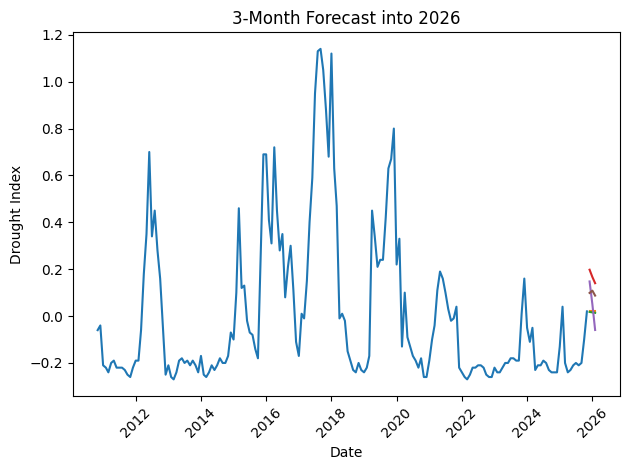

In [ ]:
plt.figure()

# Historical
plt.plot(df["date"], df["value"])

# Forecasts
plt.plot(forecast_df["date"], forecast_df["Naive"])
plt.plot(forecast_df["date"], forecast_df["ARIMA"])
plt.plot(forecast_df["date"], forecast_df["HMM"])
plt.plot(forecast_df["date"], forecast_df["XGBoost"])
plt.plot(forecast_df["date"], forecast_df["GRU"])

plt.title("3-Month Forecast into 2026")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

        date  Naive     ARIMA       HMM   XGBoost
0 2025-12-01   0.02  0.017687  0.197736  0.147700
1 2026-01-01   0.02  0.015658  0.166871  0.050843
2 2026-02-01   0.02  0.013879  0.140269 -0.059340
3 2026-03-01   0.02  0.012318  0.118530 -0.019451
4 2026-04-01   0.02  0.010950  0.099704 -0.032899
5 2026-05-01   0.02  0.009750  0.084400 -0.019649


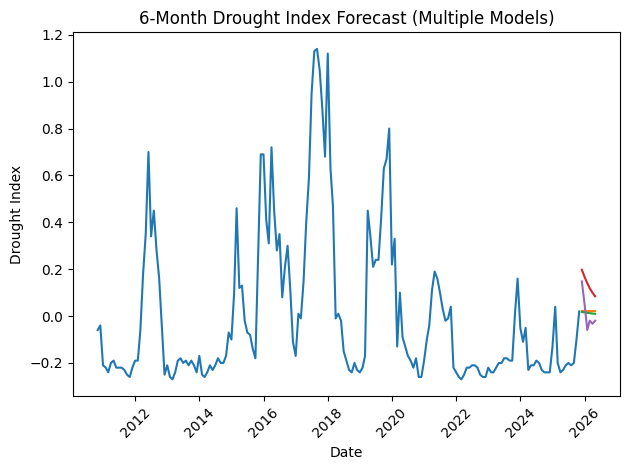

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBRegressor

# -----------------------------
# 0) Load data
# -----------------------------
df = pd.read_csv("../data/raw/assa-climate-data-national-monthly-drought-2010-11-30_2025-11-01-chirps.csv")
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df.sort_values("date").reset_index(drop=True)

y = df["value"].astype(float).values
T = len(y)

H = 6      # forecast horizon in months
LAGS = 12  # lookback for XGB

future_dates = pd.date_range(start=df["date"].iloc[-1] + pd.DateOffset(months=1), periods=H, freq="MS")

# -----------------------------
# 1) Naive persistence
# -----------------------------
naive_forecast = np.array([y[-1]] * H)

# -----------------------------
# 2) ARIMA (simple AR(1))
# -----------------------------
arima_model = ARIMA(y, order=(1,0,0)).fit()
arima_forecast = np.asarray(arima_model.forecast(steps=H))

# -----------------------------
# 3) HMM expected-value forecast
# -----------------------------
vals = y.reshape(-1, 1)
hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=300, random_state=42)
hmm.fit(vals)

post = hmm.predict_proba(vals)        # posterior probs over states
states = hmm.predict(vals)            # most likely state sequence
P = hmm.transmat_                     # transition matrix

# state means
mu = np.array([y[states == s].mean() for s in range(3)])

# forecast E[y_{t+h}] = pi_t P^h mu
pi_t = post[-1]
hmm_forecast = []
for h in range(1, H+1):
    Ph = np.linalg.matrix_power(P, h)
    pi_h = pi_t @ Ph
    hmm_forecast.append(float(pi_h @ mu))
hmm_forecast = np.array(hmm_forecast)

# Also compute wet state to get dry_prob feature for XGB
state_means = [(s, mu[s]) for s in range(3)]
wet_state = sorted(state_means, key=lambda x: x[1])[-1][0]
wet_prob = post[:, wet_state]
dry_prob = 1.0 - wet_prob

# -----------------------------
# 4) XGBoost (recursive multi-step)
# -----------------------------
def make_lag_matrix(series, regime_prob, lags=12):
    X, Y = [], []
    for t in range(lags, len(series)-1):
        X.append(np.concatenate([series[t-lags:t], [regime_prob[t]]]))
        Y.append(series[t+1])
    return np.array(X), np.array(Y)

X_full, Y_full = make_lag_matrix(y, dry_prob, lags=LAGS)

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_full, Y_full)

xgb_forecast = []
window = y[-LAGS:].copy()
reg_last = dry_prob[-1]

for _ in range(H):
    feats = np.concatenate([window, [reg_last]]).reshape(1, -1)
    pred = float(xgb.predict(feats)[0])
    xgb_forecast.append(pred)
    window = np.append(window[1:], pred)
xgb_forecast = np.array(xgb_forecast)

# -----------------------------
# 5) GRU (optional, only if gru_model exists)
# -----------------------------
gru_forecast = None
if "gru_model" in globals():
    gru_forecast = []
    win = np.column_stack([y[-LAGS:], dry_prob[-LAGS:]]).copy()
    for _ in range(H):
        pred = float(gru_model.predict(win.reshape(1, LAGS, 2), verbose=0)[0][0])
        gru_forecast.append(pred)
        win = np.vstack([win[1:], np.array([pred, reg_last])])
    gru_forecast = np.array(gru_forecast)

# -----------------------------
# 6) Assemble forecasts table
# -----------------------------
forecast_df = pd.DataFrame({
    "date": future_dates,
    "Naive": naive_forecast,
    "ARIMA": arima_forecast,
    "HMM": hmm_forecast,
    "XGBoost": xgb_forecast,
})
if gru_forecast is not None:
    forecast_df["GRU"] = gru_forecast

print(forecast_df)

# -----------------------------
# 7) Combined plot (history + forecasts)
# -----------------------------
plt.figure()
plt.plot(df["date"], y)

plt.plot(forecast_df["date"], forecast_df["Naive"])
plt.plot(forecast_df["date"], forecast_df["ARIMA"])
plt.plot(forecast_df["date"], forecast_df["HMM"])
plt.plot(forecast_df["date"], forecast_df["XGBoost"])
if "GRU" in forecast_df.columns:
    plt.plot(forecast_df["date"], forecast_df["GRU"])

plt.title("6-Month Drought Index Forecast (Multiple Models)")
plt.xlabel("Date")
plt.ylabel("Drought Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()